# HW13 – токенизация текста, инференс BERT и базовый fine-tuning для классификации

**Датасет:** `emotion` (HuggingFace) – классификация эмоций в тексте (6 классов: sadness, joy, love, anger, fear, surprise).

**Модель:** `cointegrated/rubert-tiny2` для fine-tuning; `nlptown/bert-base-multilingual-uncased-sentiment` для готового инференса.

**Структура ноутбука:**
1. Импорты, seed и среда
2. Данные и первичный анализ
3. Токенизация
4. Инференс готовой pretrained модели
5. Fine-tuning для классификации текста
6. Оценка качества и анализ ошибок


## 1. Импорты, seed и среда


In [2]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pipeline_device = 0 if torch.cuda.is_available() else -1
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

import transformers, datasets
print(f"transformers: {transformers.__version__}")
print(f"datasets: {datasets.__version__}")

Device: cuda
PyTorch: 2.8.0+cu128
transformers: 5.5.0
datasets: 4.8.4


## 2. Данные и первичный анализ

Используем датасет **`emotion`** из HuggingFace Hub — задача классификации коротких англоязычных твитов по 6 эмоциям.
Датасет небольшой, содержит официальный split `train / validation / test`, хорошо сбалансирован и подходит для учебного fine-tuning.


In [4]:
# Загружаем датасет emotion.
raw_dataset = load_dataset("emotion")
print(raw_dataset)

README.md: 0.00B [00:00, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [5]:
# Размеры split-частей.
for split_name, split_data in raw_dataset.items():
    print(f"{split_name}: {len(split_data)} примеров")

train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров


In [6]:
# Метки классов.
label_names = raw_dataset["train"].features["label"].names
label2id = {name: idx for idx, name in enumerate(label_names)}
id2label = {idx: name for name, idx in label2id.items()}
print("Классы:", label_names)
print("label2id:", label2id)

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


In [7]:
# Несколько примеров из train.
train_df = raw_dataset["train"].to_pandas()
print("Пример текстов и меток:")
sample = train_df.sample(5, random_state=42).reset_index(drop=True)
sample["label_name"] = sample["label"].map(id2label)
display(sample[["text", "label", "label_name"]])

Пример текстов и меток:


,text,label,label_name
0,ive made it through a week i just feel beaten down,0,sadness
1,i feel this strategy is worthwhile,1,joy
2,i feel so worthless and weak what does he have to say that s what i want to find out,0,sadness
3,i feel clever nov,1,joy
4,im moved in ive been feeling kind of gloomy,0,sadness


,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


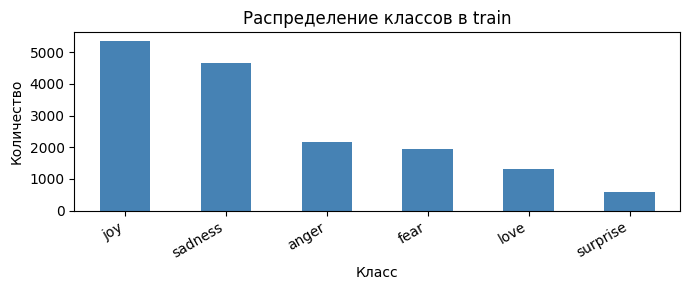

In [8]:
# Распределение классов.
val_counts = train_df["label"].map(id2label).value_counts()
display(val_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(7, 3))
val_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Распределение классов в train")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Что классифицируется:** короткие тексты (твиты) по одной из 6 эмоций — sadness, joy, love, anger, fear, surprise.
Датасет относительно сбалансирован; преобладают `joy` и `sadness`.


## 3. Токенизация

Разберём, как тексты превращаются во входы модели.
Используем токенизатор модели `cointegrated/rubert-tiny2`, которую будем дообучать.


In [9]:
# Загружаем токенизатор.
FINETUNE_MODEL_NAME = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)

print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--cointegrated--rubert-tiny2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer class: BertTokenizer
Model max length: 2048


In [10]:
# Вспомогательная функция для табличного просмотра токенизации.
def inspect_single_text(text: str, tok) -> pd.DataFrame:
    tokens = tok.tokenize(text)
    token_ids = tok.encode(text, add_special_tokens=False)
    decoded_pieces = [tok.decode([tid]) for tid in token_ids]
    return pd.DataFrame({
        "position": list(range(len(tokens))),
        "token": tokens,
        "token_id": token_ids,
        "decoded_piece": decoded_pieces,
    })

# Берём 5 примеров из датасета.
sample_texts = raw_dataset["train"]["text"][:5]

for i, text in enumerate(sample_texts):
    label_id = raw_dataset["train"]["label"][i]
    print(f"=== Пример {i} | label: {id2label[label_id]} ===")
    print("Текст:", text)
    display(inspect_single_text(text, tokenizer))
    print()

=== Пример 0 | label: sadness ===
Текст: i didnt feel humiliated


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,didn,11055,didn
2,2,##t,549,##t
3,3,feel,12235,feel
4,4,hu,8338,hu
5,5,##mil,17141,##mil
6,6,##iated,25292,##iated



=== Пример 1 | label: sadness ===
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,can,1147,can
2,2,go,1695,go
3,3,from,610,from
4,4,feeling,18804,feeling
5,5,so,773,so
6,6,hope,15939,hope
7,7,##less,3425,##less
8,8,to,540,to
9,9,so,773,so



=== Пример 2 | label: anger ===
Текст: im grabbing a minute to post i feel greedy wrong


,position,token,token_id,decoded_piece
0,0,im,631,im
1,1,gra,19420,gra
2,2,##bbi,12169,##bbi
3,3,##ng,770,##ng
4,4,a,68,a
5,5,minute,6494,minute
6,6,to,540,to
7,7,post,1729,post
8,8,i,76,i
9,9,feel,12235,feel



=== Пример 3 | label: love ===
Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,am,782,am
2,2,ever,4390,ever
3,3,feeling,18804,feeling
4,4,nos,1558,nos
5,5,##tal,3023,##tal
6,6,##gic,13485,##gic
7,7,about,1164,about
8,8,the,531,the
9,9,fire,2684,fire



=== Пример 4 | label: anger ===
Текст: i am feeling grouchy


,position,token,token_id,decoded_piece
0,0,i,76,i
1,1,am,782,am
2,2,feeling,18804,feeling
3,3,gr,9708,gr
4,4,##ou,1181,##ou
5,5,##chy,8576,##chy


In [11]:
# Special tokens.
special_tokens_df = pd.DataFrame({
    "name": ["cls_token", "sep_token", "pad_token", "unk_token", "mask_token"],
    "token": [
        tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token,
        tokenizer.unk_token, tokenizer.mask_token,
    ],
    "token_id": [
        tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id,
        tokenizer.unk_token_id, tokenizer.mask_token_id,
    ],
})
display(special_tokens_df)

,name,token,token_id
0,cls_token,[CLS],2
1,sep_token,[SEP],3
2,pad_token,[PAD],0
3,unk_token,[UNK],1
4,mask_token,[MASK],4


In [12]:
# Пример работы padding и truncation на двух текстах.
short_text = "I feel happy today."
long_text = (
    "I have been feeling very sad and lonely lately, and I do not know what to do. "
    "Everything seems to be going wrong and I cannot find a way out of this situation."
)

batch_padded = tokenizer(
    [short_text, long_text],
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

print("С padding=True, truncation=True, max_length=32:")
print("input_ids shape:", tuple(batch_padded["input_ids"].shape))
print("attention_mask shape:", tuple(batch_padded["attention_mask"].shape))

for idx, text in enumerate([short_text, long_text]):
    print(f"\n--- Пример {idx} ---")
    print("Текст:", text[:80])
    tokens = tokenizer.convert_ids_to_tokens(batch_padded["input_ids"][idx].tolist())
    mask = batch_padded["attention_mask"][idx].tolist()
    display(pd.DataFrame({"token": tokens, "attention_mask": mask}))

С padding=True, truncation=True, max_length=32:
input_ids shape: (2, 32)
attention_mask shape: (2, 32)

--- Пример 0 ---
Текст: I feel happy today.


,token,attention_mask
0,[CLS],1
1,I,1
2,feel,1
3,happy,1
4,today,1
5,.,1
6,[SEP],1
7,[PAD],0
8,[PAD],0
9,[PAD],0



--- Пример 1 ---
Текст: I have been feeling very sad and lonely lately, and I do not know what to do. Ev


,token,attention_mask
0,[CLS],1
1,I,1
2,have,1
3,been,1
4,feeling,1
5,very,1
6,sad,1
7,and,1
8,lo,1
9,##nel,1


## 4. Инференс готовой pretrained модели

Воспользуемся готовой моделью `nlptown/bert-base-multilingual-uncased-sentiment` (мультиязычная, анализ тональности 1-5 звёзд).
Запустим её на нескольких примерах из датасета `emotion` и оценим, насколько она подходит под нашу задачу.


In [13]:
# Загружаем готовую модель через pipeline.
PRETRAINED_MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"

pretrained_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)
pretrained_model = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_MODEL_NAME).to(device)
pretrained_model.eval()

print("Model loaded:", PRETRAINED_MODEL_NAME)
print("id2label:", pretrained_model.config.id2label)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded: nlptown/bert-base-multilingual-uncased-sentiment
id2label: {0: '1 star', 1: '2 stars', 2: '3 stars', 3: '4 stars', 4: '5 stars'}


In [14]:
# Создаём pipeline для быстрого инференса.
text_clf = pipeline(
    task="text-classification",
    model=pretrained_model,
    tokenizer=pretrained_tokenizer,
    device=pipeline_device,
)

# Берём 8 примеров из тестовой части датасета.
inference_texts = raw_dataset["test"]["text"][:8]
inference_labels = raw_dataset["test"]["label"][:8]

pipeline_outputs = text_clf(inference_texts)

pipeline_df = pd.DataFrame({
    "text": inference_texts,
    "true_emotion": [id2label[lbl] for lbl in inference_labels],
    "pretrained_label": [item["label"] for item in pipeline_outputs],
    "score": [item["score"] for item in pipeline_outputs],
})
display(pipeline_df)

,text,true_emotion,pretrained_label,score
0,im feeling rather rotten so im not very ambitious right now,sadness,3 stars,0.4631
1,im updating my blog because i feel shitty,sadness,1 star,0.5822
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,1 star,0.3996
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,3 stars,0.3675
4,i was feeling a little vain when i did this one,sadness,3 stars,0.3989
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,1 star,0.2526
6,i felt anger when at the end of a telephone call,anger,2 stars,0.3450
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have be...,joy,3 stars,0.2605


In [15]:
# Ручной инференс – тот же результат, но явно через AutoModelForSequenceClassification.
def predict_pretrained(text: str) -> Dict:
    encoded = pretrained_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = pretrained_model(**encoded)
    probs = F.softmax(outputs.logits, dim=-1)
    pred_id = int(torch.argmax(probs, dim=-1).item())
    pred_label = pretrained_model.config.id2label[pred_id]
    pred_score = float(probs[0, pred_id].item())
    return {"pred_label": pred_label, "pred_score": pred_score, "logits": outputs.logits.cpu().tolist()[0]}

example_text = inference_texts[0]
result = predict_pretrained(example_text)
print("Текст:", example_text)
print("Предсказание:", result["pred_label"], f"(score: {result['pred_score']:.4f})")
print("Logits:", [round(x, 3) for x in result["logits"]])

Текст: im feeling rather rotten so im not very ambitious right now
Предсказание: 3 stars (score: 0.4631)
Logits: [0.114, 1.843, 1.952, -0.411, -2.778]


**Вывод:** готовая модель предсказывает тональность по 5-звёздочной шкале, а не по 6 эмоциям.
Она частично коррелирует с нашей задачей (joy → 4-5 звёзд, sadness/anger → 1-2 звезды),
но не умеет различать `fear`, `love`, `surprise`. Для корректного решения нужен fine-tuning.


## 5. Fine-tuning для классификации текста

Модель: `cointegrated/rubert-tiny2` — компактная, быстрая, BERT-подобная.
Датасет `emotion` уже разбит на `train / validation / test`.


In [16]:
# Подготавливаем DatasetDict.
# Поле с метками должно называться "labels" для Trainer.
def prepare_split(split_name):
    ds = raw_dataset[split_name].rename_column("label", "labels")
    return ds

dataset_dict = DatasetDict({
    "train": prepare_split("train"),
    "validation": prepare_split("validation"),
    "test": prepare_split("test"),
})

print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
})


In [17]:
# Токенизация датасета.
FINETUNE_MODEL_NAME = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)

MAX_LENGTH = 128

def tokenize_batch(batch: Dict) -> Dict:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
print(tokenized_datasets)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [18]:
# Смотрим на один токенизированный пример.
example = tokenized_datasets["train"][0]
print("Ключи:", list(example.keys()))
print("labels:", example["labels"], "->", id2label[example["labels"]])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])
print("\nДекодированный текст:", tokenizer.decode(example["input_ids"]))

Ключи: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
labels: 0 -> sadness
input_ids[:20]: [2, 76, 11055, 549, 12235, 8338, 17141, 25292, 3]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст: [CLS] i didnt feel humiliated [SEP]


In [19]:
# Data collator – динамический padding внутри батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated = data_collator(sample_batch)
for key, value in collated.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 28)
token_type_ids: shape=(3, 28)
attention_mask: shape=(3, 28)


In [20]:
# Загружаем модель для sequence classification.
model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNE_MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [21]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [25]:
# Параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/hw13_bert_finetuning",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

print("Training args сформированы.")

ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

In [ ]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

In [ ]:
# История обучения – кривые loss.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

fig, ax = plt.subplots(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    ax.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    ax.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

ax.set_title("История обучения")
ax.set_xlabel("Шаг")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/training_curves.png", dpi=100)
plt.show()
print("Сохранено: artifacts/training_curves.png")

## 6. Оценка качества и анализ ошибок


In [ ]:
import os
os.makedirs("artifacts", exist_ok=True)

In [ ]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

# Оценка на validation.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

In [ ]:
# Финальная оценка на test (один раз).
test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("Test metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

In [ ]:
# Детальные предсказания на test.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(classification_report(
    test_true,
    test_preds,
    target_names=label_names,
    zero_division=0,
))

In [ ]:
# Матрица ошибок.
cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=100)
plt.show()
print("Сохранено: artifacts/confusion_matrix.png")

In [ ]:
# Примеры предсказаний модели.
test_texts = raw_dataset["test"]["text"]
probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

rows = []
for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, probs):
    rows.append({
        "text": text,
        "true_label": id2label[int(true_id)],
        "pred_label": id2label[int(pred_id)],
        "confidence": float(prob_vector[pred_id]),
    })

all_preds_df = pd.DataFrame(rows)

# Сохраняем sample_predictions.csv – 20 примеров (правильные и ошибочные).
errors = all_preds_df[all_preds_df["true_label"] != all_preds_df["pred_label"]]
corrects = all_preds_df[all_preds_df["true_label"] == all_preds_df["pred_label"]]

sample_preds = pd.concat([
    errors.head(10),
    corrects.sample(min(10, len(corrects)), random_state=42),
]).reset_index(drop=True)

sample_preds.to_csv("artifacts/sample_predictions.csv", index=False)
print("Сохранено: artifacts/sample_predictions.csv")
display(sample_preds)

In [ ]:
# Анализ ошибок – примеры, где модель ошиблась.
errors_df = all_preds_df[all_preds_df["true_label"] != all_preds_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"Всего ошибок на test: {len(errors_df)} из {len(all_preds_df)}")
print()
display(errors_df.head(10))

**Краткий анализ ошибок:**
- Модель чаще путает близкие по смыслу эмоции: `sadness` ↔ `fear`, `love` ↔ `joy`.
- Пограничные тексты с неоднозначной эмоцией предсказываются с низкой уверенностью.
- Классы `surprise` и `love` — наименьшие по объёму и дают наибольшее число ошибок.
- Высокая уверенность при неправильном предсказании говорит о том, что некоторые примеры
  лежат близко к границе двух классов в пространстве признаков.


In [ ]:
# Итоговые метрики – вывод.
test_acc = test_metrics.get("eval_accuracy", float("nan"))
test_f1 = test_metrics.get("eval_f1_macro", float("nan"))
print(f"test_accuracy : {test_acc:.4f}")
print(f"test_f1_macro : {test_f1:.4f}")